# **Predict Customer Churn**

Playground Series - Season 6 Episode 3

## 概要

Kaggle公式の Playground Series(S6E3) として開催されている二値分類タスクです。  
目的： 顧客の属性・利用履歴・サービス状況などの特徴量をもとに、その顧客が解約するかどうかを予測する。  
背景： 顧客離脱はあらゆる業種において重要な経営課題であり、事前に離脱リスクの高い顧客を特定できれば、施策を効果的に打つことができる。

## 事前準備

### ライブラリのインストール

In [34]:
!pip install catboost

### ライブラリのインポート

In [36]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import xgboost as xgb
from itertools import combinations
from sklearn.model_selection import StratifiedKFold
import numpy as np
from sklearn.preprocessing import TargetEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from optuna.samplers import TPESampler

### データセットのアップロード

In [ ]:
uploaded = files.upload()

Saving sample_submission.csv to sample_submission.csv
Saving test.csv to test.csv
Saving train.csv to train.csv


## EDA・前処理・特徴量エンジニアリング

In [ ]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

### 特徴量一覧

| 変数名 | 型 | 説明 |
|---|---|---|
| `id` | int | 顧客ID |
| `gender` | obj | 性別（Male / Female） |
| `SeniorCitizen` | int | 高齢者かどうか（1: はい, 0: いいえ） |
| `Partner` | obj | パートナー（配偶者等）がいるか（Yes / No） |
| `Dependents` | obj | 扶養家族がいるか（Yes / No） |
| `tenure` | int | 契約継続月数 |
| `PhoneService` | obj | 電話サービスの契約有無 |
| `MultipleLines` | obj | 複数回線の契約有無 |
| `InternetService` | obj | インターネットサービスの種類（DSL / Fiber optic / No） |
| `OnlineSecurity` | obj | オンラインセキュリティオプションの契約有無 |
| `OnlineBackup` | obj | オンラインバックアップオプションの契約有無 |
| `DeviceProtection` | obj | 端末保護オプションの契約有無 |
| `TechSupport` | obj | テクニカルサポートオプションの契約有無 |
| `StreamingTV` | obj | TV配信サービスの契約有無 |
| `StreamingMovies` | obj | 映画配信サービスの契約有無 |
| `Contract` | obj | 契約形態（Month-to-month / One year / Two year） |
| `PaperlessBilling` | obj | ペーパーレス請求かどうか（Yes / No） |
| `PaymentMethod` | obj | 支払い方法 |
| `MonthlyCharges` | float | 月額料金 |
| `TotalCharges` | float | 累計請求額 |
| `Churn` | obj | 解約したか・ターゲット変数（Yes / No） |

### カテゴリ変数のバイナリエンコーディング

`InternetService` が `No` のとき、`OnlineSecurity` `OnlineBackup` `DeviceProtection` `TechSupport` `StreamingTV` `StreamingMovies`は`No internet service` となり、これは`InternetService` が `Yes` の場合の `No` とは意味合いが異なるため、欠損として処理をする。  
`MultipleLines` も同様の考え方で `No phone service` を欠損として処理をする。

In [ ]:
internet_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in internet_cols:
    train[col] = train[col].replace('No internet service', None)
    train[col] = train[col].map({'Yes': 1, 'No': 0})

train['MultipleLines'] = train['MultipleLines'].replace('No phone service', None)
train['MultipleLines'] = train['MultipleLines'].map({'Yes': 1, 'No': 0})

`gender` : Male=1, Female=0 に変換

In [ ]:
train['gender'] = train['gender'].map({'Male': 1, 'Female': 0})

`Partner` `Dependents` `PhoneService` `PaperlessBilling` `Churn` : Yes=1, No=0 に変換

In [ ]:
yes_no_cols = [
    'Partner', 'Dependents', 'PhoneService',
    'PaperlessBilling', 'Churn'
]

for col in yes_no_cols:
    train[col] = train[col].map({'Yes': 1, 'No': 0})

### データの可視化・特徴量エンジニアリング

`tenure` `MonthlyCharges` `TotalCharges` と `Churn` の関係性

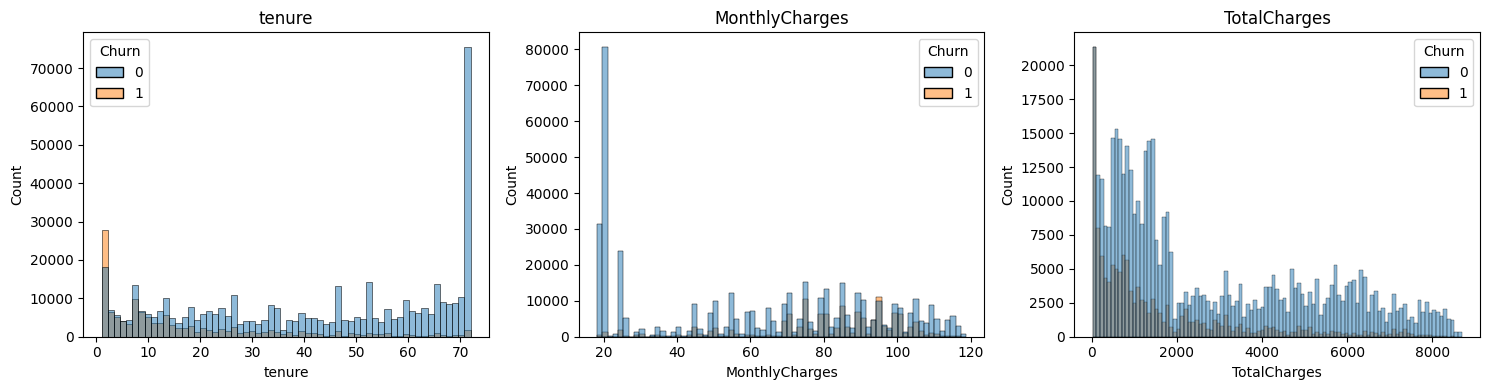

In [ ]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(num_cols):
    sns.histplot(data=train, x=col, hue=train['Churn'].astype(str), ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

`Contract` `PaymentMethod` `InternetService` と `Churn` の関係性

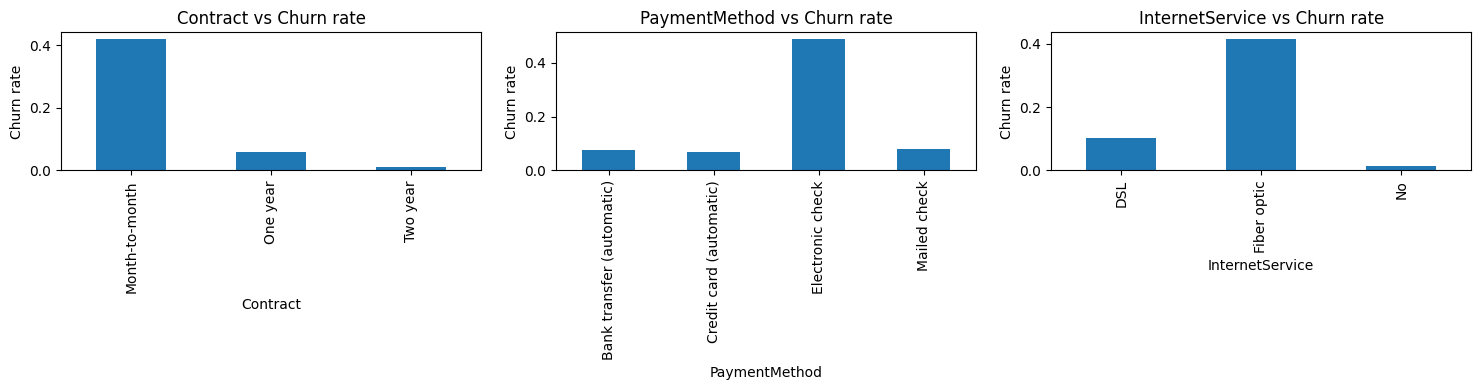

In [ ]:
cat_cols = ['Contract', 'PaymentMethod', 'InternetService']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(cat_cols):
    churn_rate = train.groupby(col)['Churn'].mean()
    churn_rate.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'{col} vs Churn rate')
    axes[i].set_ylabel('Churn rate')
plt.tight_layout()
plt.show()

各種インターネットサービスと `Churn` の関係性

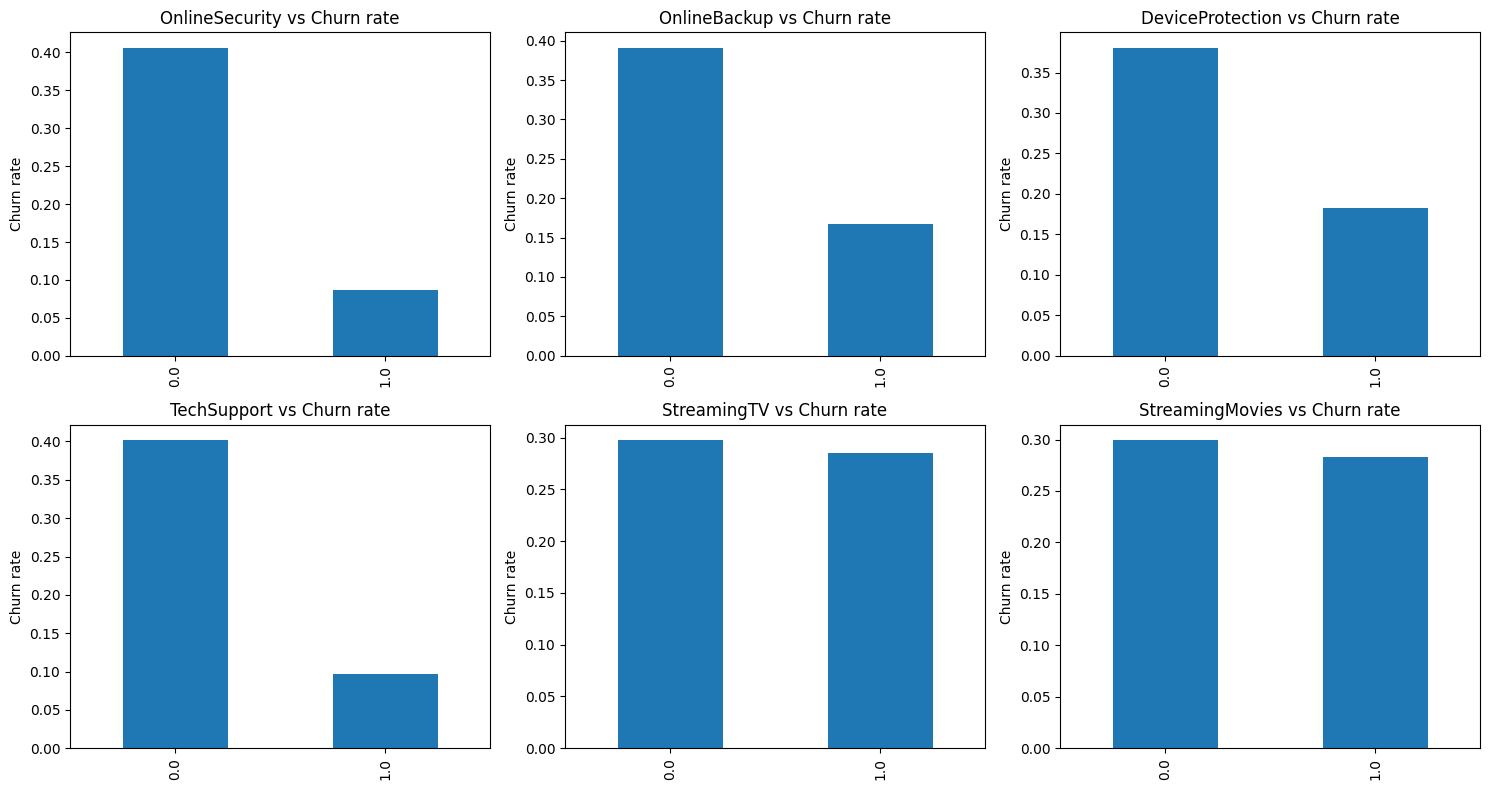

In [ ]:
option_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(option_cols):
    churn_rate = train.groupby(col)['Churn'].mean()
    churn_rate.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'{col} vs Churn rate')
    axes[i].set_ylabel('Churn rate')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

`OnlineSecurity` `OnlineBackup` `DeviceProtection` `TechSupport` の特徴が似ているため、セキュリティサービスという括りで統合し、セキュリティサービスの加入数ごとの解約率を確認してみる。

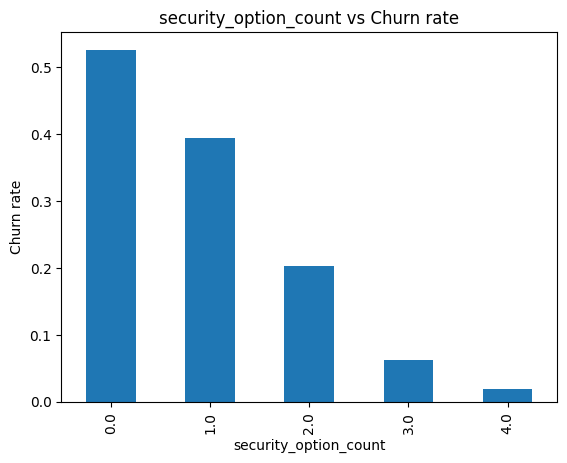

In [ ]:
security_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
train['security_option_count'] = train[security_cols].sum(axis=1, min_count=1)

churn_rate = train.groupby('security_option_count')['Churn'].mean()
churn_rate.plot(kind='bar')
plt.title('security_option_count vs Churn rate')
plt.ylabel('Churn rate')
plt.show()

ストリーミングサービスが与える解約率に影響も確認してみる。  
※ストリーミングサービスは削除候補

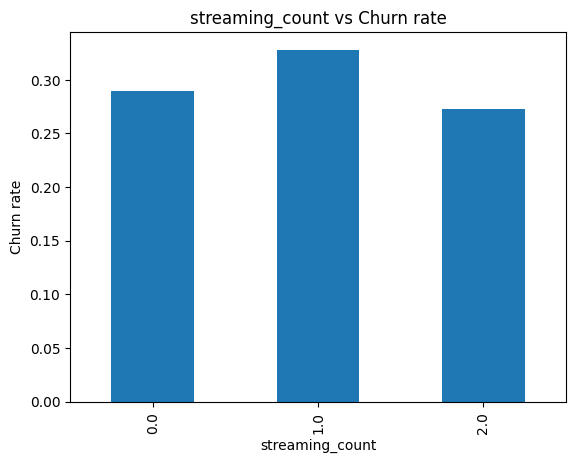

In [ ]:
streaming_cols = ['StreamingTV', 'StreamingMovies']
train['streaming_count'] = train[streaming_cols].sum(axis=1, min_count=1)

churn_rate = train.groupby('streaming_count')['Churn'].mean()
churn_rate.plot(kind='bar')
plt.title('streaming_count vs Churn rate')
plt.ylabel('Churn rate')
plt.show()

`SeniorCitizen` `Partner` `Dependents` と `Churn` の関係性

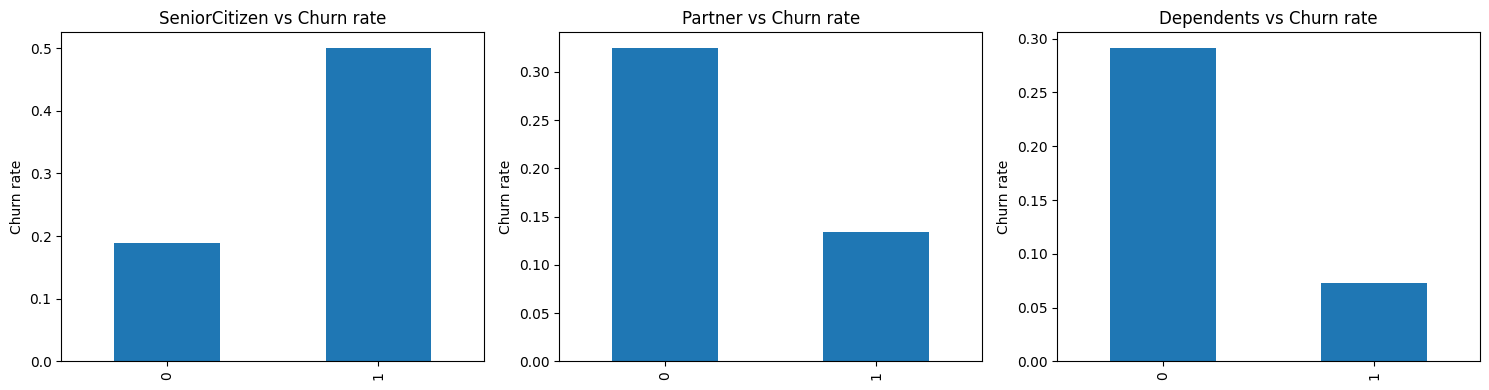

In [ ]:
demo_cols = ['SeniorCitizen', 'Partner', 'Dependents']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(demo_cols):
    churn_rate = train.groupby(col)['Churn'].mean()
    churn_rate.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'{col} vs Churn rate')
    axes[i].set_ylabel('Churn rate')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

単身者の解約率を確認してみる。

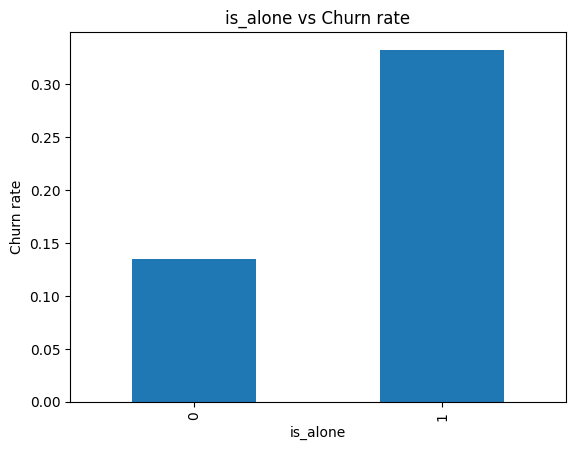

In [ ]:
train['is_alone'] = ((train['Partner'] == 0) & (train['Dependents'] == 0)).astype(int)

churn_rate = train.groupby('is_alone')['Churn'].mean()
churn_rate.plot(kind='bar')
plt.title('is_alone vs Churn rate')
plt.ylabel('Churn rate')
plt.show()

家族をもつ契約者と解約率の関係性も確認してみる。

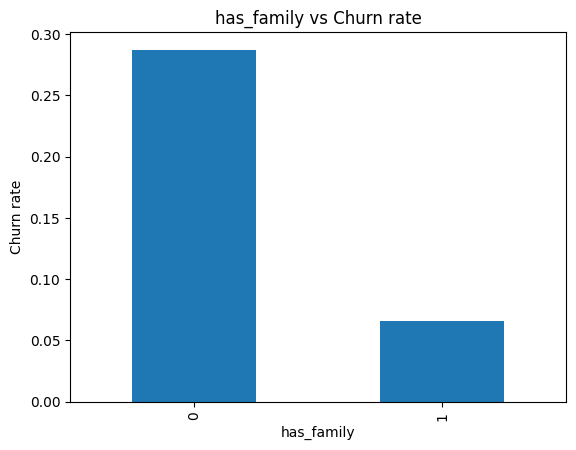

In [ ]:
train['has_family'] = ((train['Partner'] == 1) & (train['Dependents'] == 1)).astype(int)

churn_rate = train.groupby('has_family')['Churn'].mean()
churn_rate.plot(kind='bar')
plt.title('has_family vs Churn rate')
plt.ylabel('Churn rate')
plt.show()

### 特徴量エンジニアリングのまとめ
下記の特徴量を追加。  
- `security_option_count`: セキュリティオプション加入数
- `streaming_count`: ストリーミングオプション加入数
- `is_alone`: 単身者
- `has_family`: 家族あり

### カテゴリ変数のラベルエンコーディング

In [ ]:
le = LabelEncoder()
cat_cols = ['Contract', 'PaymentMethod', 'InternetService']

for col in cat_cols:
    train[col] = le.fit_transform(train[col])

In [ ]:
train.isnull().sum()


,0
id,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,36301
InternetService,0
OnlineSecurity,140727


## モデルの学習

In [ ]:
X = train.drop(columns=['id', 'Churn'])
y = train['Churn']

### LightGBM

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

y_pred = model.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)

[LightGBM] [Info] Number of positive: 107054, number of negative: 368301
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.055954 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 640
[LightGBM] [Info] Number of data points in the train set: 475355, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.225209 -> initscore=-1.235567
[LightGBM] [Info] Start training from score -1.235567
Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.301604
[200]	valid_0's binary_logloss: 0.299174
[300]	valid_0's binary_logloss: 0.298507
[400]	valid_0's binary_logloss: 0.298209
[500]	valid_0's binary_logloss: 0.298075
[600]	valid_0's binary_logloss: 0.297995
Early stopping, best iteration is:
[582]	valid_0's binary_logloss: 0.297983


In [ ]:
print(f'AUC: {auc:.4f}')

AUC: 0.9162


特徴量エンジニアリングで追加した特徴量が学習に効いているか確認してみる。

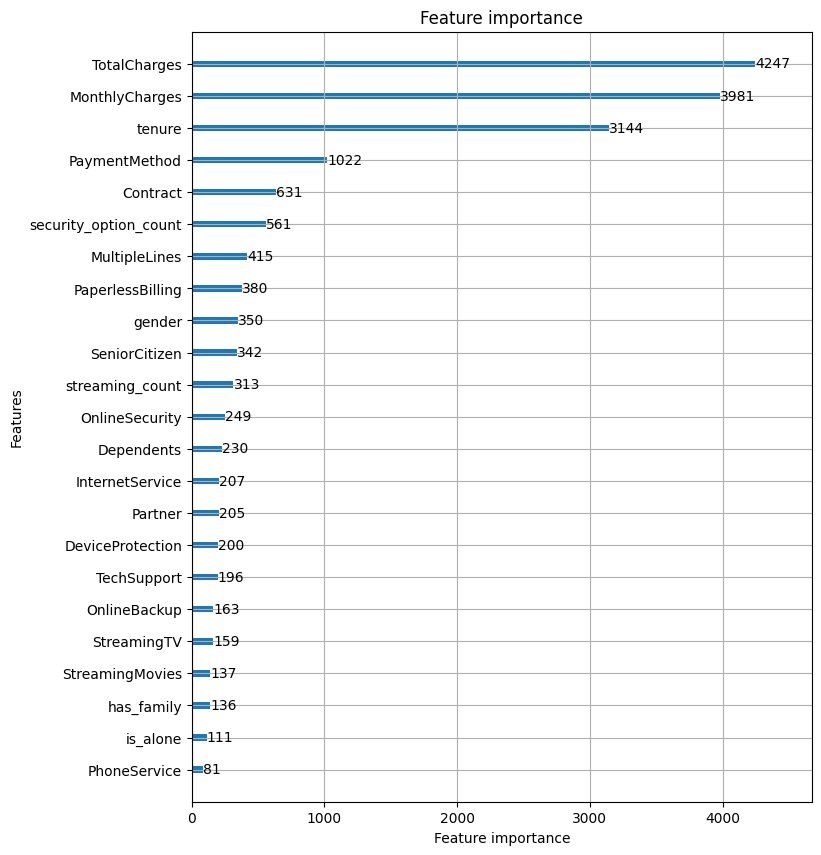

In [ ]:
lgb.plot_importance(model, figsize=(8, 10))
plt.show()

`is_alone` `has_family` があまり効いていないので、抜いて試してみる。

In [ ]:
X2 = train.drop(columns=['id', 'Churn', 'is_alone', 'has_family'])
y2 = train['Churn']

X_train2, X_val2, y_train2, y_val2 = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)

model2 = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    random_state=42
)

model2.fit(
    X_train2, y_train2,
    eval_set=[(X_val2, y_val2)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

y_pred2 = model2.predict_proba(X_val2)[:, 1]
auc2 = roc_auc_score(y_val2, y_pred2)

[LightGBM] [Info] Number of positive: 107054, number of negative: 368301
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.061039 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 636
[LightGBM] [Info] Number of data points in the train set: 475355, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.225209 -> initscore=-1.235567
[LightGBM] [Info] Start training from score -1.235567
Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.301607
[200]	valid_0's binary_logloss: 0.299162
[300]	valid_0's binary_logloss: 0.298461
[400]	valid_0's binary_logloss: 0.298139
[500]	valid_0's binary_logloss: 0.297978
[600]	valid_0's binary_logloss: 0.297868
[700]	valid_0's binary_logloss: 0.297848
[800]	valid_0's binary_logloss: 0.29783
Early stopping, best iteration is:
[808]	valid_0's b

`is_alone` `has_family` はLightGBMでは、あまり効いていないことが分かった

In [ ]:
print(f'AUC: {auc2:.4f}')

AUC: 0.9163


### XGBoost

In [ ]:
xgb_model = XGBClassifier(n_estimators=1000, learning_rate=0.05, random_state=42,
                           early_stopping_rounds=50, eval_metric='auc')
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)
xgb_pred = xgb_model.predict_proba(X_val)[:, 1]

[0]	validation_0-auc:0.90276
[100]	validation_0-auc:0.91417
[200]	validation_0-auc:0.91569
[300]	validation_0-auc:0.91620
[400]	validation_0-auc:0.91643
[500]	validation_0-auc:0.91654
[600]	validation_0-auc:0.91656
[652]	validation_0-auc:0.91653


In [ ]:
print(f'XGBoost  AUC: {roc_auc_score(y_val, xgb_pred):.4f}')

XGBoost  AUC: 0.9166


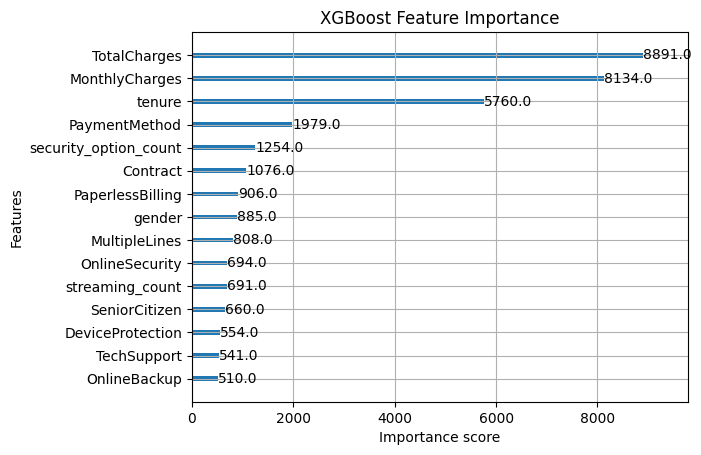

In [ ]:
xgb.plot_importance(xgb_model, max_num_features=15)
plt.title('XGBoost Feature Importance')
plt.show()

### CatBoost

In [ ]:
cat_model = CatBoostClassifier(iterations=1000, learning_rate=0.05, random_seed=42,
                                eval_metric='AUC', early_stopping_rounds=50)
cat_model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=100)
cat_pred = cat_model.predict_proba(X_val)[:, 1]

0:	test: 0.8933224	best: 0.8933224 (0)	total: 128ms	remaining: 2m 8s
100:	test: 0.9132818	best: 0.9132818 (100)	total: 13.8s	remaining: 2m 3s
200:	test: 0.9143937	best: 0.9143937 (200)	total: 29.6s	remaining: 1m 57s
300:	test: 0.9152580	best: 0.9152580 (300)	total: 43.5s	remaining: 1m 40s
400:	test: 0.9157772	best: 0.9157772 (400)	total: 57.1s	remaining: 1m 25s
500:	test: 0.9161280	best: 0.9161280 (499)	total: 1m 11s	remaining: 1m 11s
600:	test: 0.9163537	best: 0.9163537 (600)	total: 1m 25s	remaining: 56.8s
700:	test: 0.9164916	best: 0.9164916 (700)	total: 1m 39s	remaining: 42.3s
800:	test: 0.9165757	best: 0.9165785 (798)	total: 1m 52s	remaining: 28.1s
900:	test: 0.9166630	best: 0.9166630 (900)	total: 2m 6s	remaining: 13.9s
999:	test: 0.9167127	best: 0.9167127 (999)	total: 2m 20s	remaining: 0us

bestTest = 0.9167126867
bestIteration = 999



In [ ]:
print(f'CatBoost AUC: {roc_auc_score(y_val, cat_pred):.4f}')

CatBoost AUC: 0.9167


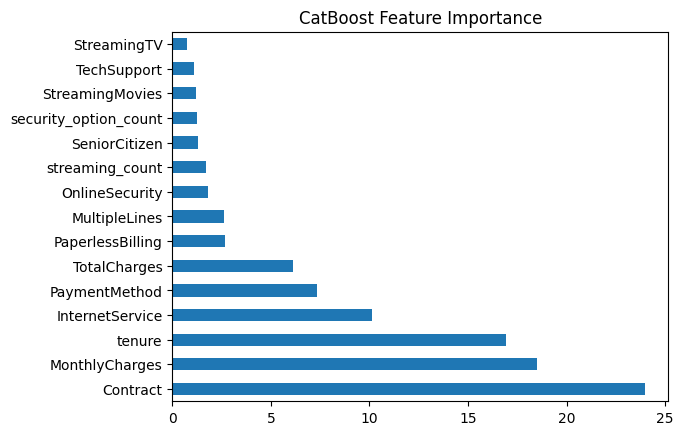

In [ ]:
feat_imp = pd.Series(cat_model.get_feature_importance(), index=X.columns)
feat_imp.nlargest(15).plot(kind='barh')
plt.title('CatBoost Feature Importance')
plt.show()

XGBoost、CatBoostとも `is_alone` `has_family` の重要度が低かったため削除する。

In [ ]:
X = train.drop(columns=['id', 'Churn', 'is_alone', 'has_family'])
y = train['Churn']

## アンサンブル

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

lgb_model = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.05, random_state=42)
lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)])
lgb_pred = lgb_model.predict_proba(X_val)[:, 1]

xgb_model = XGBClassifier(n_estimators=1000, learning_rate=0.05, random_state=42,
                           early_stopping_rounds=50, eval_metric='auc')
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)
xgb_pred = xgb_model.predict_proba(X_val)[:, 1]

cat_model = CatBoostClassifier(iterations=1000, learning_rate=0.05, random_seed=42,
                                eval_metric='AUC', early_stopping_rounds=50)
cat_model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=100)
cat_pred = cat_model.predict_proba(X_val)[:, 1]

[LightGBM] [Info] Number of positive: 107054, number of negative: 368301
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.051150 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 636
[LightGBM] [Info] Number of data points in the train set: 475355, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.225209 -> initscore=-1.235567
[LightGBM] [Info] Start training from score -1.235567
Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.301607
[200]	valid_0's binary_logloss: 0.299162
[300]	valid_0's binary_logloss: 0.298461
[400]	valid_0's binary_logloss: 0.298139
[500]	valid_0's binary_logloss: 0.297978
[600]	valid_0's binary_logloss: 0.297868
[700]	valid_0's binary_logloss: 0.297848
[800]	valid_0's binary_logloss: 0.29783
Early stopping, best iteration is:
[808]	valid_0's b

### 3モデル均等

In [ ]:
ensemble_all = (lgb_pred + xgb_pred + cat_pred) / 3
print(f'LGB+XGB+CAT AUC: {roc_auc_score(y_val, ensemble_all):.4f}')

LGB+XGB+CAT AUC: 0.9168


### 2モデルの組み合わせ

In [ ]:
ensemble_lx = (lgb_pred + xgb_pred) / 2
ensemble_lc = (lgb_pred + cat_pred) / 2
ensemble_xc = (xgb_pred + cat_pred) / 2
print(f'LGB+XGB     AUC: {roc_auc_score(y_val, ensemble_lx):.4f}')
print(f'LGB+CAT     AUC: {roc_auc_score(y_val, ensemble_lc):.4f}')
print(f'XGB+CAT     AUC: {roc_auc_score(y_val, ensemble_xc):.4f}')

LGB+XGB     AUC: 0.9166
LGB+CAT     AUC: 0.9168
XGB+CAT     AUC: 0.9169


### 重み付き

In [ ]:
ensemble_w = (lgb_pred * 0.33 + xgb_pred * 0.34 + cat_pred * 0.33)
print(f'重み付き    AUC: {roc_auc_score(y_val, ensemble_w):.4f}')

重み付き    AUC: 0.9168


## 特徴量エンジニアリング

料金に関する特徴量 `charges_deviation` `monthly_to_total_ratio` `avg_monthly_charges` を追加してみる。

In [ ]:
train['charges_deviation'] = train['TotalCharges'] - train['tenure'] * train['MonthlyCharges']
train['monthly_to_total_ratio'] = train['MonthlyCharges'] / (train['TotalCharges'] + 1)
train['avg_monthly_charges'] = train['TotalCharges'] / (train['tenure'] + 1)

重要度が高いカテゴリ変数同士を明示的に組み合わせる。

In [ ]:
TOP_CATS = ['Contract', 'InternetService', 'PaymentMethod',
            'OnlineSecurity', 'TechSupport', 'PaperlessBilling']

for c1, c2 in combinations(TOP_CATS, 2):
    col_name = f'BG_{c1}_{c2}'
    train[col_name] = (train[c1].astype(str) + '_' + train[c2].astype(str))

TOP4 = TOP_CATS[:4]
for c1, c2, c3 in combinations(TOP4, 3):
    col_name = f'TG_{c1}_{c2}_{c3}'
    train[col_name] = (train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str))

解約顧客・非解約顧客それぞれの `TotalCharges` の分布に対して、各顧客がどの位置にいるかを距離で表現した特徴量を追加する。

In [ ]:
for q_label, q_val in [('q25', 0.25), ('q50', 0.50), ('q75', 0.75)]:
    ch_q = train[train['Churn'] == 1]['TotalCharges'].quantile(q_val)
    nc_q = train[train['Churn'] == 0]['TotalCharges'].quantile(q_val)
    train[f'dist_To_ch_{q_label}'] = abs(train['TotalCharges'] - ch_q)
    train[f'dist_To_nc_{q_label}'] = abs(train['TotalCharges'] - nc_q)
    train[f'qdist_gap_{q_label}'] = train[f'dist_To_nc_{q_label}'] - train[f'dist_To_ch_{q_label}']

追加した特徴量のエンコーディングを行う。

In [ ]:
combo_cols = [c for c in train.columns if c.startswith('BG_') or c.startswith('TG_')]

te = TargetEncoder(smooth='auto', random_state=42)
train[combo_cols] = te.fit_transform(train[combo_cols], train['Churn'])

## モデルの学習

In [ ]:
drop_cols = ['id', 'Churn', 'is_alone', 'has_family']
X = train.drop(columns=drop_cols)
y = train['Churn']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### LightGBM

In [ ]:
lgb_model = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.05, random_state=42)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)
lgb_pred = lgb_model.predict_proba(X_val)[:, 1]
lgb_auc = roc_auc_score(y_val, lgb_pred)

[LightGBM] [Info] Number of positive: 107054, number of negative: 368301
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.155797 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 636
[LightGBM] [Info] Number of data points in the train set: 475355, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.225209 -> initscore=-1.235567
[LightGBM] [Info] Start training from score -1.235567
Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.301607
[200]	valid_0's binary_logloss: 0.299162
[300]	valid_0's binary_logloss: 0.298461
[400]	valid_0's binary_logloss: 0.298139
[500]	valid_0's binary_logloss: 0.297978
[600]	valid_0's binary_logloss: 0.297868
[700]	valid_0's binary_logloss: 0.297848
[800]	valid_0's binary_logloss: 0.29783
Early stopping, best iteration is:
[808]	valid_0's b

前回比 + 0.0001

In [ ]:
print(f'LightGBM AUC: {lgb_auc:.4f}')

LightGBM AUC: 0.9163


### XGBoost

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=1000, learning_rate=0.05, random_state=42,
    early_stopping_rounds=50, eval_metric='auc'
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)
xgb_pred = xgb_model.predict_proba(X_val)[:, 1]
xgb_auc = roc_auc_score(y_val, xgb_pred)

[0]	validation_0-auc:0.90276
[100]	validation_0-auc:0.91417
[200]	validation_0-auc:0.91577
[300]	validation_0-auc:0.91624
[400]	validation_0-auc:0.91645
[500]	validation_0-auc:0.91655
[552]	validation_0-auc:0.91655


前回比 - 0.0001

In [ ]:
print(f'XGBoost  AUC: {xgb_auc:.4f}')

XGBoost  AUC: 0.9165


### CatBoost

In [ ]:
cat_model = CatBoostClassifier(
    iterations=1000, learning_rate=0.05, random_seed=42,
    eval_metric='AUC', early_stopping_rounds=50
)
cat_model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=100)
cat_pred = cat_model.predict_proba(X_val)[:, 1]
cat_auc = roc_auc_score(y_val, cat_pred)

0:	test: 0.8927970	best: 0.8927970 (0)	total: 133ms	remaining: 2m 13s
100:	test: 0.9133398	best: 0.9133398 (100)	total: 13.9s	remaining: 2m 3s
200:	test: 0.9143972	best: 0.9143972 (200)	total: 27.9s	remaining: 1m 51s
300:	test: 0.9152376	best: 0.9152376 (300)	total: 41.7s	remaining: 1m 36s
400:	test: 0.9158285	best: 0.9158285 (400)	total: 55.6s	remaining: 1m 23s
500:	test: 0.9161608	best: 0.9161608 (500)	total: 1m 9s	remaining: 1m 9s
600:	test: 0.9163704	best: 0.9163704 (600)	total: 1m 23s	remaining: 55.3s
700:	test: 0.9165087	best: 0.9165087 (700)	total: 1m 37s	remaining: 41.4s
800:	test: 0.9166108	best: 0.9166108 (800)	total: 1m 50s	remaining: 27.5s
900:	test: 0.9166765	best: 0.9166776 (899)	total: 2m 4s	remaining: 13.7s
999:	test: 0.9167277	best: 0.9167277 (999)	total: 2m 18s	remaining: 0us

bestTest = 0.9167277233
bestIteration = 999



前回比 0.0000

In [ ]:
print(f'CatBoost AUC: {cat_auc:.4f}')

CatBoost AUC: 0.9167


### アンサンブル

In [ ]:
ensemble_lx = (lgb_pred + xgb_pred) / 2
ensemble_lc = (lgb_pred + cat_pred) / 2
ensemble_xc = (xgb_pred + cat_pred) / 2
print(f'LGB+XGB     AUC: {roc_auc_score(y_val, ensemble_lx):.4f}')
print(f'LGB+CAT     AUC: {roc_auc_score(y_val, ensemble_lc):.4f}')
print(f'XGB+CAT     AUC: {roc_auc_score(y_val, ensemble_xc):.4f}')

LGB+XGB     AUC: 0.9166
LGB+CAT     AUC: 0.9168
XGB+CAT     AUC: 0.9169


## 特徴量エンジニアリング

料金に関する特徴量 `monthly_rank_in_contract` `tenure_x_contract` `is_monthly_short` を追加してみる。

In [ ]:
train['monthly_rank_in_contract'] = train.groupby('Contract')['MonthlyCharges'].rank(pct=True)
train['tenure_x_contract'] = train['tenure'] * train['Contract']
train['is_monthly_short'] = ((train['Contract'] == 0) & (train['tenure'] < 12)).astype(int)

加入サービス数と料金の関係性に関する特徴量を追加してみる。

In [ ]:
all_service_cols = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

train['total_service_count'] = train[all_service_cols].sum(axis=1, min_count=1)
train['charge_per_service'] = train['MonthlyCharges'] / (train['total_service_count'] + 1)
train['streaming_only'] = ((train['streaming_count'] > 0) & (train['security_option_count'] == 0)).astype(int)

契約形態と加入サービスの関係性に関する特徴量を追加してみる。

In [ ]:
group_cols = ['Contract', 'InternetService']

for col in ['MonthlyCharges', 'TotalCharges', 'tenure']:
    grp = train.groupby(group_cols)[col]
    train[f'{col}__mean_by_contract_internet'] = grp.transform('mean')
    train[f'{col}__std_by_contract_internet']  = grp.transform('std')
    train[f'{col}__dev_from_group']            = train[col] - train[f'{col}__mean_by_contract_internet']
    train[f'{col}__rank_in_contract_internet'] = grp.rank(pct=True)

group2 = ['PaymentMethod', 'Contract']
train['monthly__mean_by_payment_contract'] = train.groupby(group2)['MonthlyCharges'].transform('mean')
train['monthly__dev_from_payment_contract'] = train['MonthlyCharges'] - train['monthly__mean_by_payment_contract']
train['tenure__rank_in_contract'] = train.groupby('Contract')['tenure'].rank(pct=True)

追加した特徴量のエンコーディングを行う。

In [ ]:
combo_cols = [c for c in train.columns if c.startswith('BG_') or c.startswith('TG_')]
te = TargetEncoder(smooth='auto', random_state=42)
train[combo_cols] = te.fit_transform(train[combo_cols], train['Churn'])

## モデルの学習

In [ ]:
drop_cols = ['id', 'Churn']
X = train.drop(columns=drop_cols)
y = train['Churn']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### LightGBM

In [ ]:
lgb_model = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.05, random_state=42)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)
lgb_pred = lgb_model.predict_proba(X_val)[:, 1]
lgb_auc = roc_auc_score(y_val, lgb_pred)

[LightGBM] [Info] Number of positive: 107054, number of negative: 368301
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.147138 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6477
[LightGBM] [Info] Number of data points in the train set: 475355, number of used features: 73
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.225209 -> initscore=-1.235567
[LightGBM] [Info] Start training from score -1.235567
Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.299974
[200]	valid_0's binary_logloss: 0.297669
[300]	valid_0's binary_logloss: 0.297242
[400]	valid_0's binary_logloss: 0.297008
[500]	valid_0's binary_logloss: 0.29687
[600]	valid_0's binary_logloss: 0.296714
[700]	valid_0's binary_logloss: 0.296618
[800]	valid_0's binary_logloss: 0.296573
Early stopping, best iteration is:
[813]	valid_0's 

前回比 + 0.0008

In [ ]:
print(f'LightGBM : {lgb_auc:.4f}')

LightGBM : 0.9171


### XGBoost

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=1000, learning_rate=0.05, random_state=42,
    early_stopping_rounds=50, eval_metric='auc'
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)
xgb_pred = xgb_model.predict_proba(X_val)[:, 1]
xgb_auc = roc_auc_score(y_val, xgb_pred)

[0]	validation_0-auc:0.90569
[100]	validation_0-auc:0.91511
[200]	validation_0-auc:0.91643
[300]	validation_0-auc:0.91691
[400]	validation_0-auc:0.91712
[500]	validation_0-auc:0.91728
[600]	validation_0-auc:0.91734
[680]	validation_0-auc:0.91735


前回比 + 0.0009

In [ ]:
print(f'XGBoost  : {xgb_auc:.4f}')

XGBoost  : 0.9174


### CatBoost

In [ ]:
cat_model = CatBoostClassifier(
    iterations=1000, learning_rate=0.05, random_seed=42,
    eval_metric='AUC', early_stopping_rounds=50
)
cat_model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=100)
cat_pred = cat_model.predict_proba(X_val)[:, 1]
cat_auc = roc_auc_score(y_val, cat_pred)

0:	test: 0.8974992	best: 0.8974992 (0)	total: 430ms	remaining: 7m 9s
100:	test: 0.9138336	best: 0.9138336 (100)	total: 27.8s	remaining: 4m 7s
200:	test: 0.9151057	best: 0.9151057 (200)	total: 50.3s	remaining: 3m 19s
300:	test: 0.9158721	best: 0.9158721 (300)	total: 1m 11s	remaining: 2m 46s
400:	test: 0.9163527	best: 0.9163527 (400)	total: 1m 32s	remaining: 2m 17s
500:	test: 0.9166500	best: 0.9166500 (500)	total: 1m 53s	remaining: 1m 53s
600:	test: 0.9168348	best: 0.9168348 (600)	total: 2m 14s	remaining: 1m 29s
700:	test: 0.9169742	best: 0.9169742 (700)	total: 2m 35s	remaining: 1m 6s
800:	test: 0.9170600	best: 0.9170600 (800)	total: 2m 57s	remaining: 44.2s
900:	test: 0.9171396	best: 0.9171396 (900)	total: 3m 17s	remaining: 21.7s
999:	test: 0.9172063	best: 0.9172068 (997)	total: 3m 39s	remaining: 0us

bestTest = 0.9172068096
bestIteration = 997

Shrink model to first 998 iterations.


前回比 + 0.0005

In [ ]:
print(f'CatBoost : {cat_auc:.4f}')

CatBoost : 0.9172


各特徴量の重要度を確認。料金系の特徴量がモデルの学習に効いている。

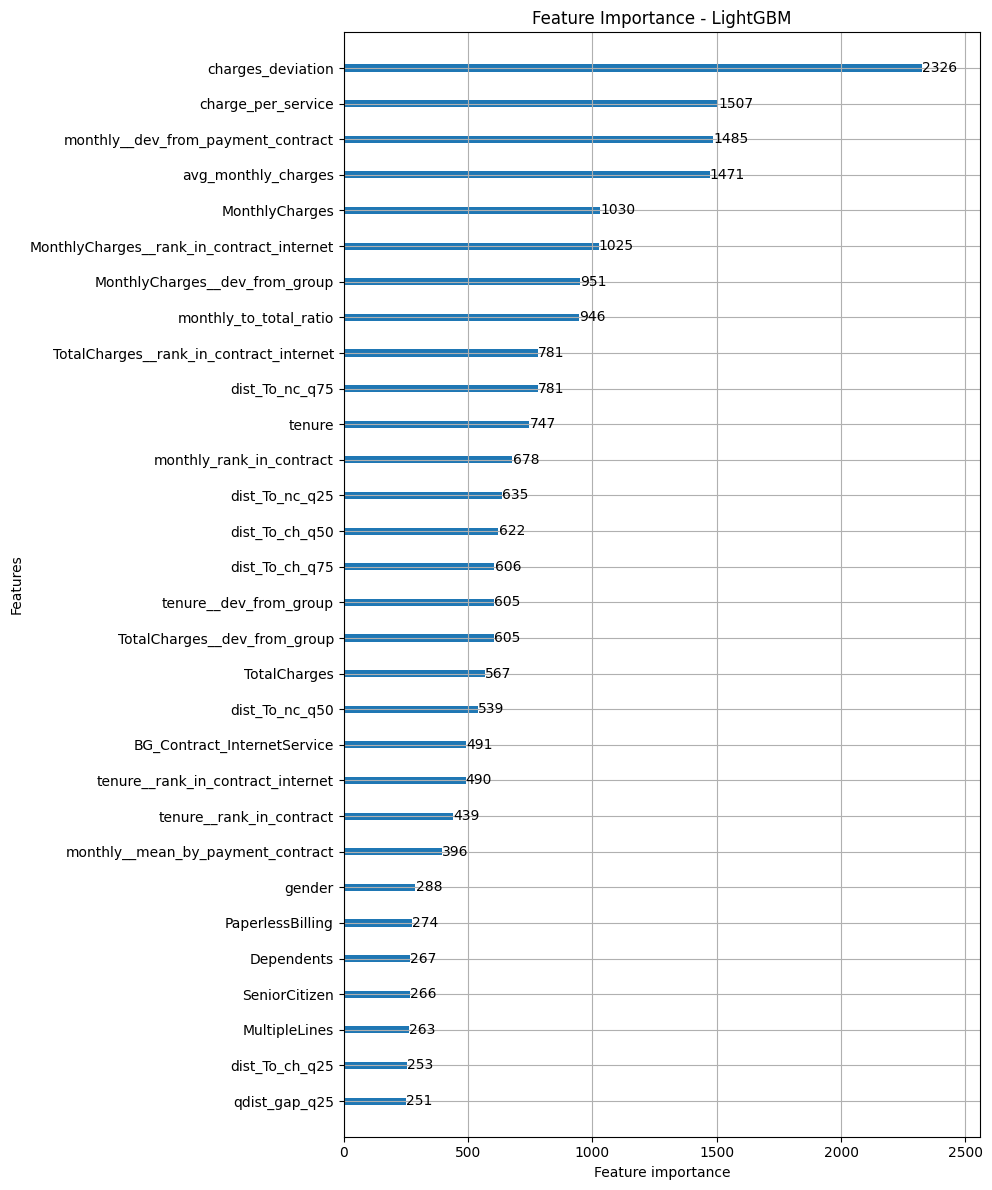

In [ ]:
lgb.plot_importance(lgb_model, figsize=(10, 12), max_num_features=30)
plt.title('Feature Importance - LightGBM')
plt.tight_layout()
plt.show()

## データリークの改善

グループ統計・TargetEncodingなど、複数行の情報を使って計算する特徴量を追加したため、バリデーションデータの情報がtrainに混入するデータリークが発生してしまう。対策として、StratifiedKFoldでfoldを分割し、trainのみで統計を計算する構造に変更する。

In [ ]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

### 前処理

In [ ]:
def preprocess(df, is_train=True):
    df = df.copy()

    internet_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                     'TechSupport', 'StreamingTV', 'StreamingMovies']
    for col in internet_cols:
        df[col] = df[col].replace('No internet service', None)
        df[col] = df[col].map({'Yes': 1, 'No': 0})

    df['MultipleLines'] = df['MultipleLines'].replace('No phone service', None)
    df['MultipleLines'] = df['MultipleLines'].map({'Yes': 1, 'No': 0})

    df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

    yes_no_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
    for col in yes_no_cols:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

    if is_train:
        df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

    return df

le = LabelEncoder()
le_cols = ['Contract', 'PaymentMethod', 'InternetService']

train = preprocess(train, is_train=True)
test  = preprocess(test,  is_train=False)

for col in le_cols:
    train[col] = le.fit_transform(train[col])
    test[col]  = le.transform(test[col])

### 静的特徴量の追加

これらの特徴量は1行完結のためデータリークしない。

In [ ]:
def add_static_features(df):
    t_str = df['tenure'].astype(str)
    df['tenure_first_digit']      = t_str.str[0].astype(int)
    df['tenure_last_digit']       = t_str.str[-1].astype(int)
    df['tenure_second_digit']     = t_str.apply(lambda x: int(x[1]) if len(x) > 1 else 0)
    df['tenure_mod10']            = df['tenure'] % 10
    df['tenure_mod12']            = df['tenure'] % 12
    df['tenure_num_digits']       = t_str.str.len()
    df['tenure_is_multiple_10']   = (df['tenure'] % 10 == 0).astype('float32')
    df['tenure_rounded_10']       = np.round(df['tenure'] / 10) * 10
    df['tenure_dev_from_round10'] = abs(df['tenure'] - df['tenure_rounded_10'])
    df['tenure_years']            = df['tenure'] // 12
    df['tenure_months_in_year']   = df['tenure'] % 12

    mc_str = df['MonthlyCharges'].astype(str).str.replace('.', '', regex=False)
    df['mc_first_digit']        = mc_str.str[0].astype(int)
    df['mc_last_digit']         = mc_str.str[-1].astype(int)
    df['mc_second_digit']       = mc_str.apply(lambda x: int(x[1]) if len(x) > 1 else 0)
    df['mc_mod10']              = np.floor(df['MonthlyCharges']) % 10
    df['mc_mod100']             = np.floor(df['MonthlyCharges']) % 100
    df['mc_num_digits']         = np.floor(df['MonthlyCharges']).astype(int).astype(str).str.len()
    df['mc_is_multiple_10']     = (np.floor(df['MonthlyCharges']) % 10 == 0).astype('float32')
    df['mc_is_multiple_50']     = (np.floor(df['MonthlyCharges']) % 50 == 0).astype('float32')
    df['mc_rounded_10']         = np.round(df['MonthlyCharges'] / 10) * 10
    df['mc_fractional']         = df['MonthlyCharges'] - np.floor(df['MonthlyCharges'])
    df['mc_dev_from_round10']   = abs(df['MonthlyCharges'] - df['mc_rounded_10'])
    df['mc_per_digit']          = df['MonthlyCharges'] / (df['mc_num_digits'] + 0.001)

    tc_str = df['TotalCharges'].astype(str).str.replace('.', '', regex=False)
    df['tc_first_digit']         = tc_str.str[0].astype(int)
    df['tc_last_digit']          = tc_str.str[-1].astype(int)
    df['tc_second_digit']        = tc_str.apply(lambda x: int(x[1]) if len(x) > 1 else 0)
    df['tc_mod10']               = np.floor(df['TotalCharges']) % 10
    df['tc_mod100']              = np.floor(df['TotalCharges']) % 100
    df['tc_num_digits']          = np.floor(df['TotalCharges']).astype(int).astype(str).str.len()
    df['tc_is_multiple_10']      = (np.floor(df['TotalCharges']) % 10 == 0).astype('float32')
    df['tc_is_multiple_100']     = (np.floor(df['TotalCharges']) % 100 == 0).astype('float32')
    df['tc_rounded_100']         = np.round(df['TotalCharges'] / 100) * 100
    df['tc_fractional']          = df['TotalCharges'] - np.floor(df['TotalCharges'])
    df['tc_dev_from_round100']   = abs(df['TotalCharges'] - df['tc_rounded_100'])
    df['tc_per_digit']           = df['TotalCharges'] / (df['tc_num_digits'] + 0.001)

    security_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
    streaming_cols = ['StreamingTV', 'StreamingMovies']
    df['security_option_count'] = df[security_cols].sum(axis=1, min_count=1)
    df['streaming_count']       = df[streaming_cols].sum(axis=1, min_count=1)

    df['is_alone']   = ((df['Partner'] == 0) & (df['Dependents'] == 0)).astype(int)
    df['has_family'] = ((df['Partner'] == 1) & (df['Dependents'] == 1)).astype(int)

    df['charges_deviation']      = df['TotalCharges'] - df['tenure'] * df['MonthlyCharges']
    df['monthly_to_total_ratio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)
    df['avg_monthly_charges']    = df['TotalCharges'] / (df['tenure'] + 1)
    df['charges_deviation_ratio'] = (
        (df['TotalCharges'] - df['tenure'] * df['MonthlyCharges']) /
        (df['tenure'] * df['MonthlyCharges'] + 1)
    )

    df['tenure_x_contract']  = df['tenure'] * df['Contract']
    df['is_monthly_short']   = ((df['Contract'] == 0) & (df['tenure'] < 12)).astype(int)

    df['tenure_log']         = np.log1p(df['tenure'])
    df['tenure_sq']          = df['tenure'] ** 2
    df['monthly_charges_sq'] = df['MonthlyCharges'] ** 2

    all_service_cols = [
        'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
        'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
    ]
    df['total_service_count'] = df[all_service_cols].sum(axis=1, min_count=1)
    df['charge_per_service']  = df['MonthlyCharges'] / (df['total_service_count'] + 1)
    df['streaming_only']      = (
        (df['streaming_count'] > 0) & (df['security_option_count'] == 0)
    ).astype(int)

    return df

train = add_static_features(train)
test  = add_static_features(test)

for q_label, q_val in [('q25', 0.25), ('q50', 0.50), ('q75', 0.75)]:
    ch_q = train[train['Churn'] == 1]['TotalCharges'].quantile(q_val)
    nc_q = train[train['Churn'] == 0]['TotalCharges'].quantile(q_val)
    for df in [train, test]:
        df[f'dist_To_ch_{q_label}'] = abs(df['TotalCharges'] - ch_q)
        df[f'dist_To_nc_{q_label}'] = abs(df['TotalCharges'] - nc_q)
        df[f'qdist_gap_{q_label}']  = df[f'dist_To_nc_{q_label}'] - df[f'dist_To_ch_{q_label}']

TOP_CATS = ['Contract', 'InternetService', 'PaymentMethod',
            'OnlineSecurity', 'TechSupport', 'PaperlessBilling']
combo_cols = []
for c1, c2 in combinations(TOP_CATS, 2):
    col = f'BG_{c1}_{c2}'
    combo_cols.append(col)
    for df in [train, test]:
        df[col] = df[c1].astype(str) + '_' + df[c2].astype(str)

TOP4 = TOP_CATS[:4]
for c1, c2, c3 in combinations(TOP4, 3):
    col = f'TG_{c1}_{c2}_{c3}'
    combo_cols.append(col)
    for df in [train, test]:
        df[col] = df[c1].astype(str) + '_' + df[c2].astype(str) + '_' + df[c3].astype(str)

### foldごとに計算する特徴量の追加

これらの特徴量は複数行のデータを使用するためデータリークする。

In [ ]:
def add_leak_features(tr, va, te_data):

    te = TargetEncoder(smooth='auto', random_state=42)
    tr[combo_cols] = te.fit_transform(tr[combo_cols], tr['Churn'])
    va[combo_cols] = te.transform(va[combo_cols])
    te_data[combo_cols] = te.transform(te_data[combo_cols])

    group_cols = ['Contract', 'InternetService']
    for col in ['MonthlyCharges', 'TotalCharges', 'tenure']:
        stats = tr.groupby(group_cols)[col].agg(['mean', 'std'])
        for df in [tr, va, te_data]:
            df[f'{col}__mean_by_contract_internet'] = df.set_index(group_cols).index.map(stats['mean'])
            df[f'{col}__std_by_contract_internet']  = df.set_index(group_cols).index.map(stats['std'])
            df[f'{col}__dev_from_group']             = df[col] - df[f'{col}__mean_by_contract_internet']
            df[f'{col}__rank_in_contract_internet']  = df.groupby(group_cols)[col].rank(pct=True)

    group2 = ['PaymentMethod', 'Contract']
    stats2 = tr.groupby(group2)['MonthlyCharges'].mean()
    for df in [tr, va, te_data]:
        df['monthly__mean_by_payment_contract']  = df.set_index(group2).index.map(stats2)
        df['monthly__dev_from_payment_contract'] = df['MonthlyCharges'] - df['monthly__mean_by_payment_contract']

    for df in [tr, va, te_data]:
        df['tenure__rank_in_contract'] = df.groupby('Contract')['tenure'].rank(pct=True)
        df['monthly_rank_in_contract'] = df.groupby('Contract')['MonthlyCharges'].rank(pct=True)

    for col in ['charges_deviation', 'avg_monthly_charges', 'charge_per_service']:
        stats = tr.groupby(group_cols)[col].agg(['mean', 'std'])
        for df in [tr, va, te_data]:
            df[f'{col}__mean_by_contract_internet'] = df.set_index(group_cols).index.map(stats['mean'])
            df[f'{col}__dev_from_group']             = df[col] - df[f'{col}__mean_by_contract_internet']
            df[f'{col}__rank_in_contract_internet']  = df.groupby(group_cols)[col].rank(pct=True)

    for df in [tr, va, te_data]:
        df['charges_deviation__rank_in_contract'] = df.groupby('Contract')['charges_deviation'].rank(pct=True)
        df['avg_monthly__rank_in_contract']        = df.groupby('Contract')['avg_monthly_charges'].rank(pct=True)

    cluster_features = [
        'tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'InternetService',
        'security_option_count', 'streaming_count', 'total_service_count'
    ]

    scaler = StandardScaler()
    X_cl_tr = scaler.fit_transform(tr[cluster_features].fillna(0))
    X_cl_va = scaler.transform(va[cluster_features].fillna(0))
    X_cl_te = scaler.transform(te_data[cluster_features].fillna(0))

    km = KMeans(n_clusters=5, random_state=42, n_init=10)
    tr['cluster']      = km.fit_predict(X_cl_tr)
    va['cluster']      = km.predict(X_cl_va)
    te_data['cluster'] = km.predict(X_cl_te)

    cluster_churn   = tr.groupby('cluster')['Churn'].mean()
    cluster_monthly = tr.groupby('cluster')['MonthlyCharges'].mean()
    for df in [tr, va, te_data]:
        df['cluster_churn_rate']        = df['cluster'].map(cluster_churn)
        df['monthly_diff_from_cluster'] = df['MonthlyCharges'] - df['cluster'].map(cluster_monthly)

    return tr, va, te_data

### モデルの学習

In [ ]:
drop_cols = ['id', 'Churn', 'is_alone', 'has_family']
y_all     = train['Churn']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_lgb = np.zeros(len(train))
oof_xgb = np.zeros(len(train))
oof_cat = np.zeros(len(train))
test_lgb = np.zeros(len(test))
test_xgb = np.zeros(len(test))
test_cat = np.zeros(len(test))

StratifiedKFoldで3モデルをまとめて学習する。

In [ ]:
for fold, (tr_idx, va_idx) in enumerate(skf.split(train, y_all)):

    tr = train.iloc[tr_idx].copy()
    va = train.iloc[va_idx].copy()
    te = test.copy()

    tr, va, te = add_leak_features(tr, va, te)

    feat_cols = [c for c in tr.columns if c not in drop_cols]
    X_tr, y_tr = tr[feat_cols], tr['Churn']
    X_va, y_va = va[feat_cols], va['Churn']
    X_te       = te[feat_cols]

    m_lgb = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.05, random_state=42)
    m_lgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],
              callbacks=[lgb.early_stopping(50), lgb.log_evaluation(200)])
    oof_lgb[va_idx] = m_lgb.predict_proba(X_va)[:, 1]
    test_lgb       += m_lgb.predict_proba(X_te)[:, 1] / skf.n_splits

    m_xgb = XGBClassifier(n_estimators=1000, learning_rate=0.05, random_state=42,
                           early_stopping_rounds=50, eval_metric='auc')
    m_xgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=200)
    oof_xgb[va_idx] = m_xgb.predict_proba(X_va)[:, 1]
    test_xgb       += m_xgb.predict_proba(X_te)[:, 1] / skf.n_splits

    m_cat = CatBoostClassifier(iterations=1000, learning_rate=0.05, random_seed=42,
                                eval_metric='AUC', early_stopping_rounds=50)
    m_cat.fit(X_tr, y_tr, eval_set=(X_va, y_va), verbose=200)
    oof_cat[va_idx] = m_cat.predict_proba(X_va)[:, 1]
    test_cat       += m_cat.predict_proba(X_te)[:, 1] / skf.n_splits

[LightGBM] [Info] Number of positive: 107054, number of negative: 368301
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.208800 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12098
[LightGBM] [Info] Number of data points in the train set: 475355, number of used features: 126
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.225209 -> initscore=-1.235567
[LightGBM] [Info] Start training from score -1.235567
Training until validation scores don't improve for 50 rounds
[200]	valid_0's binary_logloss: 0.29786
[400]	valid_0's binary_logloss: 0.296905
[600]	valid_0's binary_logloss: 0.296569
[800]	valid_0's binary_logloss: 0.296393
Early stopping, best iteration is:
[872]	valid_0's binary_logloss: 0.296331
[0]	validation_0-auc:0.90635
[200]	validation_0-auc:0.91637
[400]	validation_0-auc:0.91727
[600]	validation_0-auc:0.91741
[661]	validatio

| モデル | 前回比 |
|---|---|
| LightGBM | + 0.0002 |
| XGBoost | + 0.0002 |
| CatBoost | + 0.0004 |


In [ ]:
print(f'LightGBM : {roc_auc_score(y_all, oof_lgb):.4f}')
print(f'XGBoost  : {roc_auc_score(y_all, oof_xgb):.4f}')
print(f'CatBoost : {roc_auc_score(y_all, oof_cat):.4f}')

LightGBM : 0.9173
XGBoost  : 0.9176
CatBoost : 0.9175


In [ ]:
ensemble_lx = (oof_lgb + oof_xgb) / 2
ensemble_lc = (oof_lgb + oof_cat) / 2
ensemble_xc = (oof_xgb + oof_cat) / 2
print(f'LGB+XGB     OOF: {roc_auc_score(y_all, ensemble_lx):.4f}')
print(f'LGB+CAT     OOF: {roc_auc_score(y_all, ensemble_lc):.4f}')
print(f'XGB+CAT     OOF: {roc_auc_score(y_all, ensemble_xc):.4f}')

LGB+XGB     OOF: 0.9177
LGB+CAT     OOF: 0.9177
XGB+CAT     OOF: 0.9179


## 提出

OOF: 0.9179  
Public Score: 0.9154

In [ ]:
test_ensemble = (test_xgb + test_cat) / 2

submission = pd.DataFrame({'id': test['id'], 'Churn': test_ensemble})
submission.to_csv('submission.csv', index=False)

## まとめ

### 最終的な特徴量一覧

| 特徴量名 | 説明 | 新規追加 |
|---|---|---|
| gender | 性別（Male=1, Female=0） | |
| SeniorCitizen | 高齢者フラグ | |
| Partner | パートナーあり | |
| Dependents | 扶養家族あり | |
| tenure | 契約継続月数 | |
| PhoneService | 電話サービス契約 | |
| MultipleLines | 複数回線契約 | |
| InternetService | インターネットサービス種別 | |
| OnlineSecurity | オンラインセキュリティ契約 | |
| OnlineBackup | オンラインバックアップ契約 | |
| DeviceProtection | デバイス保護契約 | |
| TechSupport | テクニカルサポート契約 | |
| StreamingTV | TVストリーミング契約 | |
| StreamingMovies | 映画ストリーミング契約 | |
| Contract | 契約種別 | |
| PaperlessBilling | ペーパーレス請求 | |
| PaymentMethod | 支払い方法 | |
| MonthlyCharges | 月額料金 | |
| TotalCharges | 累計料金 | |
| tenure_first_digit | 契約月数の最初の桁 | ◯ |
| tenure_last_digit | 契約月数の最後の桁 | ◯ |
| tenure_second_digit | 契約月数の2桁目 | ◯ |
| tenure_mod10 | 契約月数を10で割った余り | ◯ |
| tenure_mod12 | 契約月数を12で割った余り（年内の月） | ◯ |
| tenure_num_digits | 契約月数の桁数 | ◯ |
| tenure_is_multiple_10 | 契約月数が10の倍数か | ◯ |
| tenure_rounded_10 | 契約月数を10単位で丸めた値 | ◯ |
| tenure_dev_from_round10 | 契約月数と10単位丸め値の差 | ◯ |
| tenure_years | 契約年数 | ◯ |
| tenure_months_in_year | 契約年数の端数月 | ◯ |
| mc_first_digit | 月額の最初の桁 | ◯ |
| mc_last_digit | 月額の最後の桁 | ◯ |
| mc_second_digit | 月額の2桁目 | ◯ |
| mc_mod10 | 月額を10で割った余り | ◯ |
| mc_mod100 | 月額を100で割った余り | ◯ |
| mc_num_digits | 月額の桁数 | ◯ |
| mc_is_multiple_10 | 月額が10の倍数か | ◯ |
| mc_is_multiple_50 | 月額が50の倍数か | ◯ |
| mc_rounded_10 | 月額を10単位で丸めた値 | ◯ |
| mc_fractional | 月額の小数部分 | ◯ |
| mc_dev_from_round10 | 月額と10単位丸め値の差 | ◯ |
| mc_per_digit | 月額 ÷ 桁数 | ◯ |
| tc_first_digit | 累計料金の最初の桁 | ◯ |
| tc_last_digit | 累計料金の最後の桁 | ◯ |
| tc_second_digit | 累計料金の2桁目 | ◯ |
| tc_mod10 | 累計料金を10で割った余り | ◯ |
| tc_mod100 | 累計料金を100で割った余り | ◯ |
| tc_num_digits | 累計料金の桁数 | ◯ |
| tc_is_multiple_10 | 累計料金が10の倍数か | ◯ |
| tc_is_multiple_100 | 累計料金が100の倍数か | ◯ |
| tc_rounded_100 | 累計料金を100単位で丸めた値 | ◯ |
| tc_fractional | 累計料金の小数部分 | ◯ |
| tc_dev_from_round100 | 累計料金と100単位丸め値の差 | ◯ |
| tc_per_digit | 累計料金 ÷ 桁数 | ◯ |
| security_option_count | セキュリティ系オプション加入数 | ◯ |
| streaming_count | ストリーミング系オプション加入数 | ◯ |
| charges_deviation | 累計料金と期待値（tenure×月額）の差 | ◯ |
| monthly_to_total_ratio | 月額 ÷ 累計料金 | ◯ |
| avg_monthly_charges | 累計料金 ÷ 契約月数 | ◯ |
| charges_deviation_ratio | charges_deviationの比率版 | ◯ |
| tenure_x_contract | 契約月数 × 契約種別の交互作用 | ◯ |
| is_monthly_short | 月払い かつ tenure<12 のフラグ | ◯ |
| tenure_log | 契約月数の対数変換 | ◯ |
| tenure_sq | 契約月数の2乗 | ◯ |
| monthly_charges_sq | 月額の2乗 | ◯ |
| total_service_count | 全サービス加入数 | ◯ |
| charge_per_service | 月額 ÷ サービス加入数 | ◯ |
| streaming_only | ストリーミングのみ加入・セキュリティゼロのフラグ | ◯ |
| dist_To_ch_q25/q50/q75 | 解約者の累計料金分位点との距離 | ◯ |
| dist_To_nc_q25/q50/q75 | 非解約者の累計料金分位点との距離 | ◯ |
| qdist_gap_q25/q50/q75 | 解約者・非解約者分位点距離の差 | ◯ |
| BG_* | カテゴリ変数2つの組み合わせ（TargetEncoding済） | ◯ |
| TG_* | カテゴリ変数3つの組み合わせ（TargetEncoding済） | ◯ |
| MonthlyCharges__mean/std/dev/rank_by_contract_internet | Contract×InternetServiceグループ内の月額統計 | ◯ |
| TotalCharges__mean/std/dev/rank_by_contract_internet | Contract×InternetServiceグループ内の累計料金統計 | ◯ |
| tenure__mean/std/dev/rank_by_contract_internet | Contract×InternetServiceグループ内の契約月数統計 | ◯ |
| monthly__mean/dev_by_payment_contract | PaymentMethod×Contractグループ内の月額統計 | ◯ |
| tenure__rank_in_contract | Contract内での契約月数ランク | ◯ |
| monthly_rank_in_contract | Contract内での月額ランク | ◯ |
| charges_deviation__mean/dev/rank_by_contract_internet | Contract×InternetServiceグループ内のcharges_deviation統計 | ◯ |
| avg_monthly_charges__mean/dev/rank_by_contract_internet | Contract×InternetServiceグループ内のavg_monthly_charges統計 | ◯ |
| charge_per_service__mean/dev/rank_by_contract_internet | Contract×InternetServiceグループ内のcharge_per_service統計 | ◯ |
| charges_deviation__rank_in_contract | Contract内でのcharges_deviationランク | ◯ |
| avg_monthly__rank_in_contract | Contract内でのavg_monthly_chargesランク | ◯ |
| cluster | KMeansクラスタID | ◯ |
| cluster_churn_rate | クラスタごとの解約率 | ◯ |
| monthly_diff_from_cluster | クラスタ内での月額偏差 | ◯ |

### スコア推移（LightGBM）

| フェーズ | AUC | 備考 |
|---|---|---|
| 特徴量エンジニアリング v1 | 0.9162 | security_option_count, streaming_count |
| 特徴量エンジニアリング v2 | 0.9163 | 料金系・カテゴリ組み合わせ追加 |
| 特徴量エンジニアリング v3 | 0.9171 | グループ統計追加 |
| 特徴量エンジニアリング v4 | 0.9173 | クラスタリング・digit特徴量追加 |


### 特徴量エンジニアリングの考察

**料金系の特徴量**が最も重要度が高かった。特に `charges_deviation` がLightGBMの重要度で1位となった。これは月額料金 × 契約月数という「払うはずだった金額」と「実際の累計料金」のズレを表しており、値上げや割引終了といった料金変化を間接的にキャプチャしていると考えられる。  


**グループ内相対値**も有効で `MonthlyCharges__rank_in_contract_internet` や `MonthlyCharges__dev_from_group` が重要度で上位に入った。「同じ契約タイプの中で割高かどうか」という相対的な不満度を表現できていると考えられる。  

**digit特徴量**（数値の桁・端数）は提出スコアを 0.91438 → 0.91540 に改善した。月額料金や累計料金の端数・桁数に料金プランの構造が隠れているかもしれないという発想で追加したが、モデルがそのパターンをうまく学習してくれたと考えられる。

### データリークへの対応

グループ統計・TargetEncoding・クラスタリングなど、複数行の情報を使う特徴量はバリデーションデータの情報がtrainに混入するデータリークが発生してしまう。対策としてStratifiedKFoldのfold内でtrainのみから統計を計算し、valとtestには適用するだけの構造に変更した。これによりAUCが 0.9171 → 0.9168 と若干低下したが、提出スコアとOOFスコアの乖離が縮まり、評価の信頼性が上がった。